In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Zomato-data.csv')
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3/5,0,100,Dining
144,New Indraprasta,No,No,3.3/5,0,150,Dining
145,Anna Kuteera,Yes,No,4.0/5,771,450,Dining
146,Darbar,No,No,3.0/5,98,800,Dining


In [4]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   name                         148 non-null    str  
 1   online_order                 148 non-null    str  
 2   book_table                   148 non-null    str  
 3   rate                         148 non-null    str  
 4   votes                        148 non-null    int64
 5   approx_cost(for two people)  148 non-null    int64
 6   listed_in(type)              148 non-null    str  
dtypes: int64(2), str(5)
memory usage: 12.7 KB


In [6]:
df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df['rate']

0      4.1/5
1      4.1/5
2      3.8/5
3      3.7/5
4      3.8/5
       ...  
143    3.3/5
144    3.3/5
145    4.0/5
146    3.0/5
147    3.9/5
Name: rate, Length: 148, dtype: str

In [3]:
df['rate']=df['rate'].str.replace('/5','',regex=False)
df

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet
...,...,...,...,...,...,...,...
143,Melting Melodies,No,No,3.3,0,100,Dining
144,New Indraprasta,No,No,3.3,0,150,Dining
145,Anna Kuteera,Yes,No,4.0,771,450,Dining
146,Darbar,No,No,3.0,98,800,Dining


In [15]:
df['rate']=df['rate'].astype(float)

In [16]:
df['rate'].dtype

dtype('float64')

In [17]:
df['listed_in(type)'].value_counts()

listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64

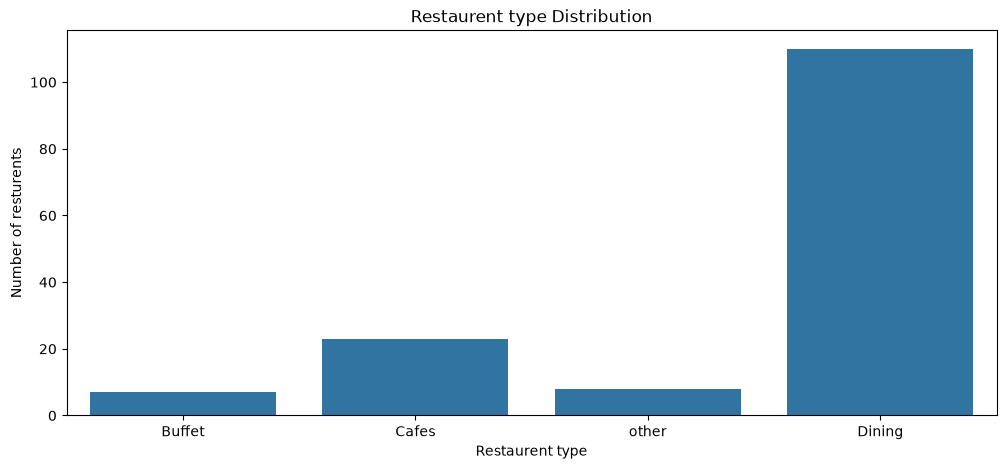

In [22]:
plt.figure(figsize=(12,5))
sns.countplot(x=df['listed_in(type)'])
plt.xlabel("Restaurent type")
plt.ylabel("Number of resturents")
plt.title("Restaurent type Distribution")
plt.show()

In [4]:
df.groupby('listed_in(type)')['votes'].sum()

listed_in(type)
Buffet     3028
Cafes      6434
Dining    20363
other      9367
Name: votes, dtype: int64

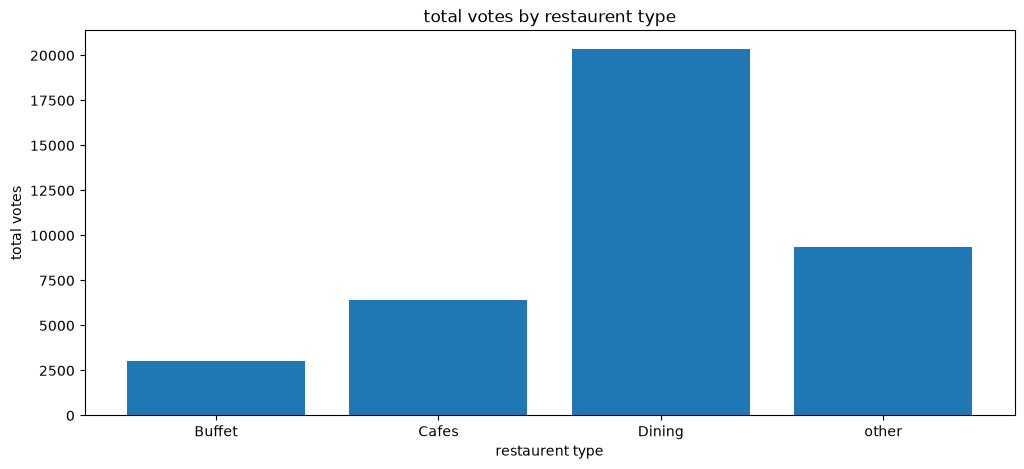

In [12]:
votes_by_type=df.groupby('listed_in(type)')['votes'].sum()
plt.figure(figsize=(12,5))
plt.bar(votes_by_type.index,votes_by_type.values)
plt.xlabel("restaurent type")
plt.ylabel("total votes")
plt.title("total votes by restaurent type")
plt.show()

In [9]:
df.loc[df['votes'].argmax()]

name                           Empire Restaurant
online_order                                 Yes
book_table                                    No
rate                                       4.4/5
votes                                       4884
approx_cost(for two people)                  750
listed_in(type)                            other
Name: 38, dtype: object

In [13]:
df['online_order'].value_counts()

online_order
No     90
Yes    58
Name: count, dtype: int64

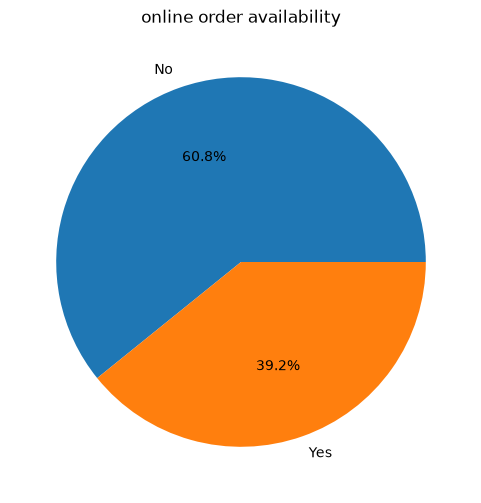

In [14]:
online_order_counts=df['online_order'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(online_order_counts.values,labels=online_order_counts.index,autopct='%1.1f%%')
plt.title('online order availability')
plt.show()

In [4]:
df['rate'].value_counts().sort_index()

rate
2.6      1
2.8      2
2.9      7
3.0      2
3.1      7
3.2      7
3.3     14
3.4     12
3.5      6
3.6     11
3.7     15
3.8     19
3.8      1
3.9     10
4.0     10
4.1     11
4.2      8
4.3      1
4.4      2
4.6      2
Name: count, dtype: int64

In [6]:
df['approx_cost(for two people)'].value_counts().sort_index()

approx_cost(for two people)
100     6
150    16
200    16
250     6
300    23
350     3
400    15
450     6
500    14
550     3
600    13
650     2
700     5
750     3
800    12
850     2
900     2
950     1
Name: count, dtype: int64

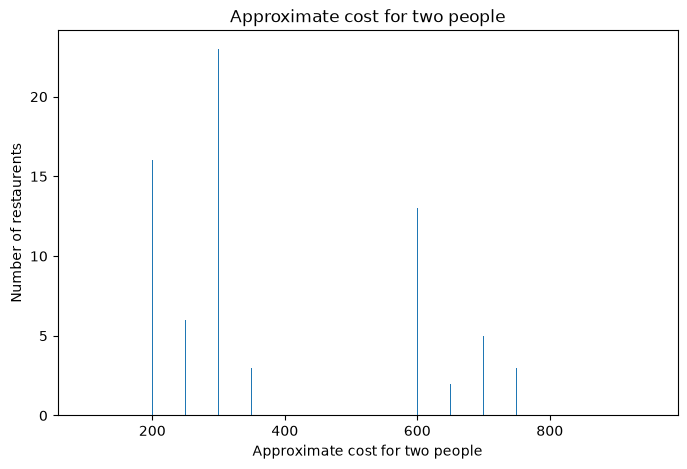

In [7]:
cost_counts=df['approx_cost(for two people)'].value_counts().sort_index()
plt.figure(figsize=(8,5))
plt.bar(cost_counts.index,cost_counts.values)
plt.xlabel("Approximate cost for two people")
plt.ylabel("Number of restaurents")
plt.title("Approximate cost for two people")
plt.show()

In [16]:
df.groupby('online_order')['rate'].mean()

online_order
No     3.487778
Yes    3.858621
Name: rate, dtype: float64

In [13]:
df['rate'].dtype

<StringDtype(na_value=nan)>

In [14]:
df['rate']=df['rate'].astype(float)

In [15]:
df['rate'].dtype

dtype('float64')

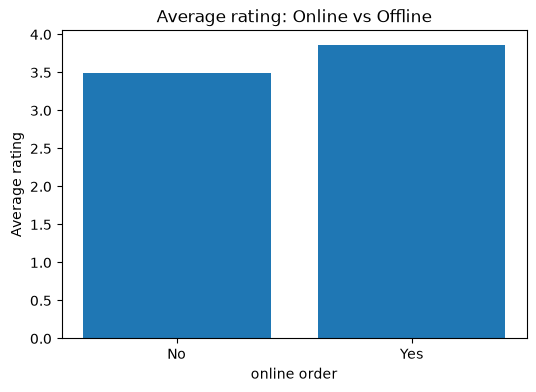

In [18]:
rating_by_order=df.groupby('online_order')['rate'].mean()
plt.figure(figsize=(6,5))
plt.bar(rating_by_order.index,rating_by_order.values)
plt.xlabel("online order")
plt.ylabel("Average rating")
plt.title("Average rating: Online vs Offline")
plt.show()